In [1]:
import os
import os.path as op
import pandas as pd
import numpy as np
import nibabel as nib
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt

datapool_root_folder = '/mnt_AdaBD_largefiles/Data/DNumRisk_Data'#. #'/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk'
dataset = 'smile' #'numberline'  #
bids_folder = op.join(datapool_root_folder, f'ds-{dataset}')

subList = [int(d[4:]) for d in os.listdir(bids_folder) if d.startswith('sub-')]
group_mapping = pd.DataFrame({'group':[int(d[4]) for d in os.listdir(bids_folder) if d.startswith('sub-')]},index=subList)
group_mapping['group'] = group_mapping['group'].map({1:'DD',2:'DD',3:'control'}) # works for both datasets


In [2]:
derivative_obj_name = 'g-aligned' # '_funcCM' # 'lambdas_space-fsaverag5'#
sessions = '1-2'
tasks ='magjudge' # 'digitorder' if dataset=='numberline' else 'magjudge-placevalue-rest'#  'rest'  #
dataset_spec = f'ds-{dataset}, task-{tasks}'

n_gradients = 3
gms = {f'g{i+1}': [] for i in range(n_gradients)}
    
sub_array = []
for sub in subList:
    sub_folder = op.join(bids_folder,'derivatives','gradients',f'sub-{sub:03d}')
    fn = op.join(sub_folder, f'sub-{sub}_ses-{sessions}_task-{tasks}_{derivative_obj_name}.npy')
    if not op.exists(fn):
        print(f'File not found: {fn}')
        continue
    gm= np.load(fn)
    for i in range(n_gradients):
        gms[f'g{i+1}'].append(gm[i, :])
    sub_array.append(int(sub))

In [3]:
#sub_array = np.array([int(i) for i in subList])

dfs = []
for i in range(n_gradients):
    gradient_df = pd.DataFrame(gms[f'g{i+1}'], index=sub_array)
    gradient_df.index.name = 'subject'
    gradient_df = gradient_df.join(group_mapping, on='subject').set_index('group', append=True)
    gradient_df['n_gradient'] = i + 1
    dfs.append(gradient_df.set_index('n_gradient', append=True))
df_gms = pd.concat(dfs).sort_index(ascending=False) #.sort_index(level='n_gradient')


In [4]:
grad_variance = df_gms.std(axis=1).to_frame(name='grad_std')
grad_minmaxdiff = (df_gms.max(axis=1) - df_gms.min(axis=1)).to_frame(name='grad_minmaxdiff')

grad_stats = pd.concat([grad_variance, grad_minmaxdiff], axis=1)


grad_std - normal distribution (fail to reject H0)
grad_std - not normal distribution (reject H0)
grad_std - normal distribution (fail to reject H0)


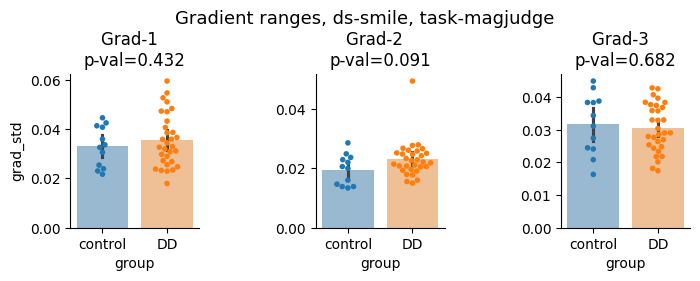

In [38]:
import seaborn as sns
alpha = 0.05
specification = ''
figure, axes = plt.subplots(1, 3,figsize = (2*4,2), sharey=False)

for i,n_grad in enumerate([1,2,3]):
    y_var =  'grad_std'#'grad_minmaxdiff' #
    tmp = grad_stats.xs(n_grad, level='n_gradient')#.drop(64)

    sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False, ax=axes[i])
    sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=4,legend=False, ax=axes[i])
    _, pval_normal = normaltest(tmp[y_var])
    if pval_normal > alpha:
            print(f'{y_var} - normal distribution (fail to reject H0)')
            stats = ttest_ind(tmp.xs('control',0,'group')[y_var], tmp.xs('DD',0,'group')[y_var], axis=0, equal_var=False)
    else: # non parametric test
            print(f'{y_var} - not normal distribution (reject H0)')    
            stats = mannwhitneyu(tmp.xs('control',0,'group')[y_var], tmp.xs('DD',0,'group')[y_var], axis=0)
    axes[i].set(title=f'Grad-{n_grad}  \np-val={stats.pvalue:.3f}',xlabel='group') #,ylim=[0.02, 0.065])
    axes[i].set_ylabel(y_var) if i==0 else axes[i].set_ylabel(None)
    sns.despine()
figure.suptitle(f'Gradient ranges, {dataset_spec}  ', y=1.2, fontsize=13)
figure.subplots_adjust(wspace=0.9)

## NPC

In [26]:
from utils import get_NPC_mask, get_basic_mask

nprf_r2 = get_NPC_mask()
mask, labeling_noParcel = get_basic_mask()

np.shape(nprf_r2)

(20484,)

In [41]:
# 2D dispersion measure
n_grad = 'both 2D'

g1 = np.array(gms[f'g1']).T
g2 = np.array(gms[f'g2']).T

G1_net = g1[nprf_r2]
G2_net = g2[nprf_r2]
G_net = np.stack([G1_net, G2_net], axis=-1)  # shape: number of nodes in network x N x 2

centroid_cog_net = np.nanmedian(G_net, axis=0)  # shape: N x 2

# Compute the 2D Euclidean distance between each node and the centroid for each subject
dist_nodes_to_centroid = G_net - centroid_cog_net  # shape: number of nodes in network x N x 2
squared_distances = np.sum(dist_nodes_to_centroid**2, axis=-1)  # sum squares across 2D (last axis), shape: number of nodes in network x N

# Compute the within-network dispersion as the mean squared distance
NPC_2d_dispersion =  np.nanmean(squared_distances, axis=0)  # shape: N

df = pd.DataFrame(NPC_2d_dispersion.T, index=sub_array, columns=['NPC_2D_dispersion'])
df.index.name = 'subject'
df = df.join(group_mapping, on='subject').set_index('group',append=True).sort_index(ascending=False)

NPC_2D_dispersion - not normal distribution (reject H0)
MannwhitneyuResult(statistic=150.0, pvalue=0.3364433766105327)


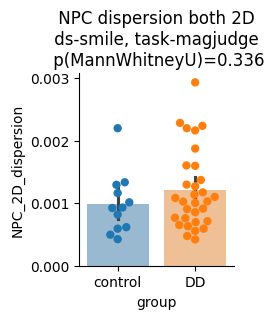

In [42]:
y_var = 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion' # #  'NPC_centroid' # 

tmp = df.copy()

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs('control',0,'group')[y_var], tmp.xs('DD',0,'group')[y_var], axis=0, equal_var=False)
        test_name = 't-test'
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs('control',0,'group')[y_var], tmp.xs('DD',0,'group')[y_var], axis=0)
        test_name = 'MannWhitneyU'
axes.set(title=f' NPC dispersion {n_grad} \n {dataset_spec} \n p({test_name})={stats.pvalue:.3f}',ylabel=y_var, xlabel='group') #,ylim=[0,30])
sns.despine()
print(stats)



## Eccentricity

In [29]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]

atlas_spec = 'CAatlas'

In [30]:
nets_of_interest = [1, 2, 5]  # visual, somato-motor, default , 3, 5, 9

df_eccentricities = []

for n_network in nets_of_interest:
    net_mask = np.where(caNets_fsav5_mapping == (n_network))[0]
    g1 = np.array(gms[f'g1']).T[net_mask]
    g2 = np.array(gms[f'g2']).T[net_mask]
    g3 = np.array(gms[f'g3']).T[net_mask]

    eccentricities = np.sqrt(g1**2 + g2**2 + g3**2)
    df_eccentricities.append(pd.DataFrame(np.nanmean(eccentricities, axis=0), index=sub_array, columns=[CAatlas_names.loc[n_network]['Network Name']]))
 
df_eccentricities = pd.concat(df_eccentricities, axis=1)
df_eccentricities.index.name = 'subject'
df_eccentricities = df_eccentricities.join(group_mapping, on='subject').set_index('group',append=True)

Visual1 - not normal distribution (reject H0)
MannwhitneyuResult(statistic=73.0, pvalue=0.6960114412839662)
Visual2 - not normal distribution (reject H0)
MannwhitneyuResult(statistic=83.0, pvalue=0.35839939733154413)
Dorsal-attention - not normal distribution (reject H0)
MannwhitneyuResult(statistic=84.0, pvalue=0.33112629553118983)


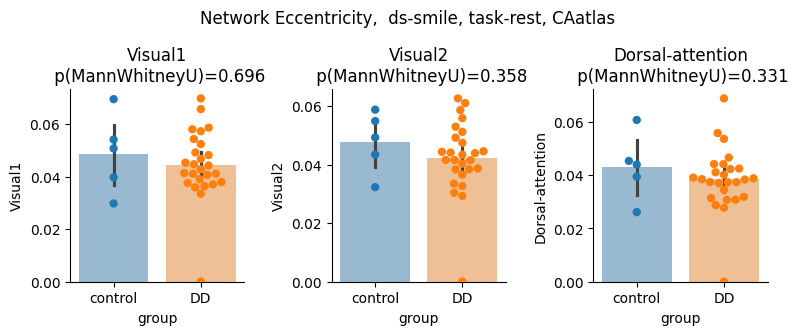

In [31]:
tmp = df_eccentricities.copy().sort_index(ascending=False)
fig, axs = plt.subplots(1,len(nets_of_interest), figsize=(3*len(nets_of_interest), 2.5))
for i, y_var in enumerate(df_eccentricities.columns):
        axes = axs[i]
        sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False, ax=axes)
        sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False, ax=axes)
        _, pval_normal = normaltest(tmp[y_var])
        if pval_normal > alpha:
                print(f'{y_var} - normal distribution (fail to reject H0)')
                stats = ttest_ind(tmp.xs('control',0,'group')[y_var], tmp.xs('DD',0,'group')[y_var], axis=0, equal_var=False)
                test_name = 't-test'
        else: # non parametric test
                print(f'{y_var} - not normal distribution (reject H0)')    
                stats = mannwhitneyu(tmp.xs('control',0,'group')[y_var], tmp.xs('DD',0,'group')[y_var], axis=0)
                test_name = 'MannWhitneyU'
        axes.set(title=f'{y_var}\n p({test_name})={stats.pvalue:.3f}',ylabel=f'{y_var}', xlabel='group') #,ylim=[0,30])
        sns.despine()

        print(stats)

fig.suptitle(f'Network Eccentricity,  {dataset_spec}, {atlas_spec}', y=1.2)
fig.subplots_adjust(wspace=0.5)

## Between task differences within subjects

In [4]:
from utils import get_gradients_tasks
tasks = 'magjudge-placevalue-rest'#['rest', 'magjudge', 'placevalue']
df_gms_tasks  = get_gradients_tasks(subList, bids_folder=bids_folder)
df_gms_tasks = df_gms_tasks.join(group_mapping, on='subject').set_index('group', append=True).sort_index(ascending=False)

df_gm_std_tasks = pd.DataFrame(df_gms_tasks.std(axis=1), columns=['std']).unstack('task').droplevel(0,axis=1)
df_gm_std_tasks = df_gm_std_tasks.reorder_levels(['group',  'subject','n_gradient']).sort_index(ascending=[False, True, True])


File not found: /mnt_AdaBD_largefiles/Data/DNumRisk_Data/ds-smile/derivatives/gradients/sub-207/sub-207_ses-1-2_task-placevalue_g-aligned.npy


In [7]:
from itertools import combinations
task_combis = [f'{task1}-{task2}' for task1, task2 in combinations(tasks.split('-'),2)]

df_gm_std_tasks_diff = df_gm_std_tasks.copy()
for task1, task2 in combinations(tasks.split('-'),2):
    df_gm_std_tasks_diff[f'{task1}-{task2}'] = df_gm_std_tasks_diff[task2] - df_gm_std_tasks_diff[task1]

df_gm_std_tasks_diff = pd.DataFrame(df_gm_std_tasks_diff[task_combis].stack(), columns=['std_diff'])
#df_gm_std_tasks_diff = df_gm_std_tasks_diff.join(group_mapping, on='subject').set_index('group', append=True)

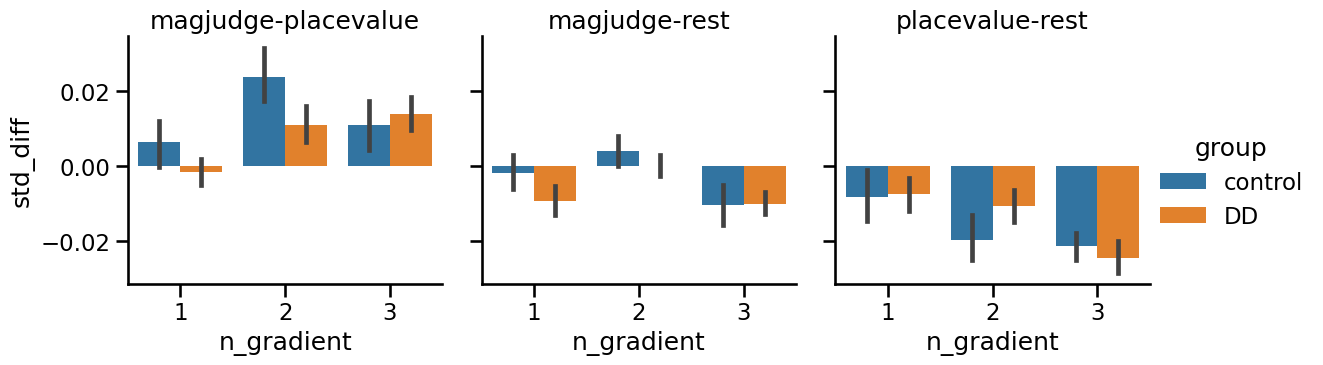

In [8]:
import seaborn as sns
sns.set_context('talk')
g = sns.catplot(data=df_gm_std_tasks_diff.reset_index(), hue='group', y='std_diff',x='n_gradient',col= 'task',kind='bar', height=4, aspect=1, legend=True)
g.set_titles(col_template="{col_name}", row_template="{row_name}")


std_diff - normal distribution (fail to reject H0)
TtestResult(statistic=2.159069675592499, pvalue=0.043989538956626245, df=18.793800290710045)


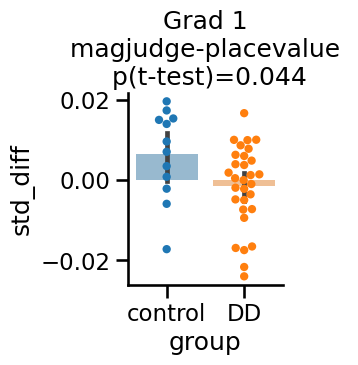

In [9]:
y_var = 'std_diff' # 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion' # #  'NPC_centroid' #

task_dyad = 'magjudge-placevalue'
n_grad = 1
tmp = df_gm_std_tasks_diff.xs((task_dyad, n_grad), level=('task','n_gradient'))

alpha = 0.05
figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs('control',0,'group')[y_var], tmp.xs('DD',0,'group')[y_var], axis=0, equal_var=False)
        test_name = 't-test'
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs('control',0,'group')[y_var], tmp.xs('DD',0,'group')[y_var], axis=0)
        test_name = 'MannWhitneyU'
axes.set(title=f' Grad {n_grad} \n {task_dyad} \n p({test_name})={stats.pvalue:.3f}',ylabel=y_var, xlabel='group') #,ylim=[0,30])
sns.despine()
print(stats)



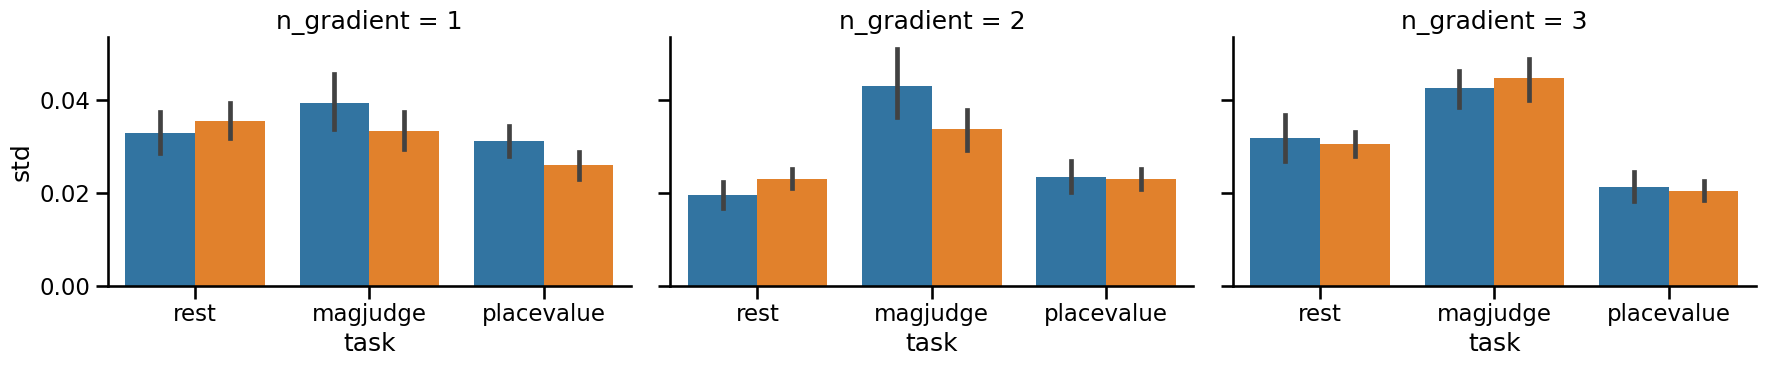

In [ ]:
df_gm_std_tasks = pd.DataFrame(df_gm_std_tasks.stack(), columns=['std'])
df_gm_std_tasks.index = df_gm_std_tasks.index.set_levels( pd.CategoricalIndex(tasks, ordered=True),level='task')

sns.catplot(data=df_gm_std_tasks.reset_index(), hue='group', y='std',col='n_gradient',x= 'task',order=tasks, kind='bar', height=4, aspect=1.5, legend=False)

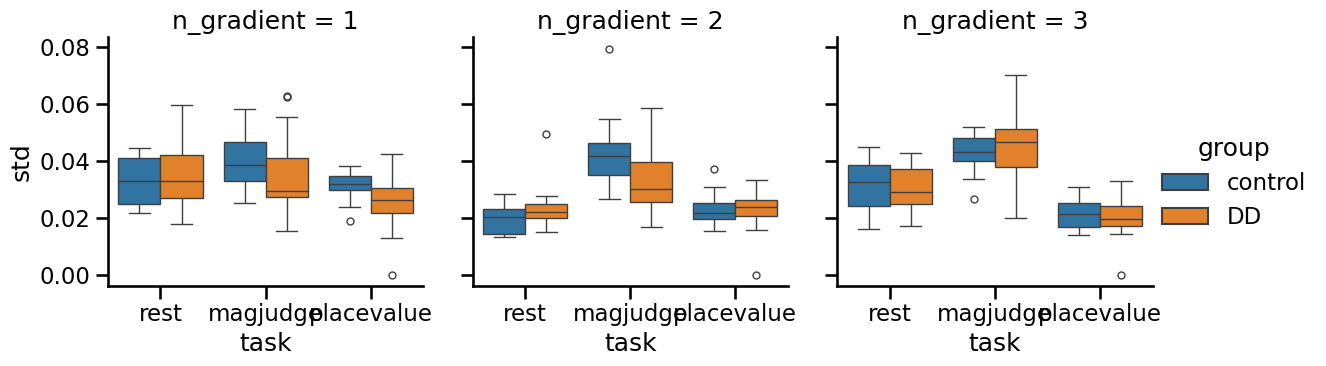

In [ ]:
task_order = ['rest', 'magjudge', 'placevalue']

df = df_gm_std_tasks.reset_index().copy()
df['task'] = pd.Categorical(df['task'], categories=task_order, ordered=True)

sns.catplot(
    data=df,
    x='task',            # use the actual task name, not numbers
    y='std',
    hue='group',
    col='n_gradient',
    kind='box',
    order=task_order, 
    #hue_order = ['magjudge', 'placevalue', 'rest'],
    height=4,
    aspect=1
)
## WRONG!@!

## Inspect single sub gradients

In [16]:
max_index = df[y_var].idxmax() 
max_index

(306, 'control')

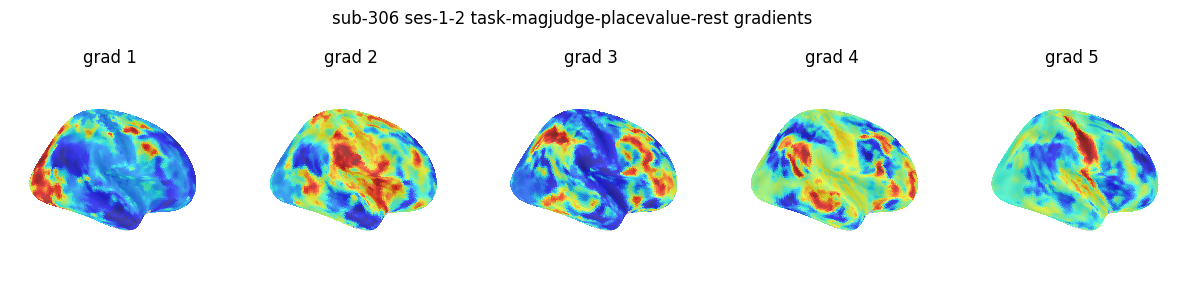

In [4]:
from utils import plot_grads

derivative_obj_name = 'gradients' # '_funcCM' # 'lambdas_space-fsaverag5'#
sub = 306
sub_folder = op.join(bids_folder,'derivatives','gradients',f'sub-{sub:03d}')
fn = op.join(sub_folder, f'sub-{sub}_ses-{sessions}_task-{tasks}_{derivative_obj_name}.npy')
gm= np.load(fn)
plot_grads(gm, f'sub-{sub} ses-{sessions} task-{tasks} {derivative_obj_name}')

## compare to amount of data

for smile dataset ∂N_sessions & ∂tasks!

In [43]:

data_amount = pd.read_csv(op.join(bids_folder,'derivatives','correlation_matrices',f'usable_frames_per_subject_ses-1-2_tasks-{tasks}.csv'), index_col=0)

In [44]:
df_comb = df.join(data_amount['usable_frames'], on='subject')

magjudge


PearsonRResult(statistic=0.23352651468551133, pvalue=0.13177538185710463)

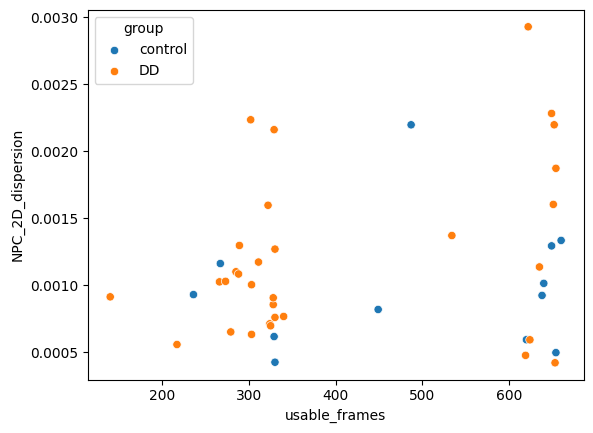

In [48]:
print(tasks)
sns.scatterplot(data=df_comb.reset_index(), x='usable_frames', y='NPC_2D_dispersion', hue='group')
# correlate
from scipy.stats import pearsonr
stats = pearsonr(df_comb['usable_frames'], df_comb['NPC_2D_dispersion'])
stats

In [49]:
300 * 2.3 / 60

11.5